**Determinants of Hepatitis B Surface Antibody in the U.S. Population: Integrating Epidemiologic Modeling and Explainable Machine Learning Using NHANES 2021-2023**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from google.colab import files

Load dataset for analysis

In [3]:
# 1. Upload your SAS files (train + test sets)
uploaded = files.upload()

Saving nhanesai1.sas7bdat to nhanesai1.sas7bdat


In [4]:
# 1. Upload your SAS files (train + test sets)
uploaded = files.upload()

Saving nhanesai2.sas7bdat to nhanesai2.sas7bdat


**Importing the dataset and take a look at it**

In [5]:
# 3. Read SAS datasets
train = pd.read_sas("nhanesai1.sas7bdat", format="sas7bdat", encoding="latin1")
test = pd.read_sas("nhanesai2.sas7bdat", format="sas7bdat", encoding="latin1")

In [6]:
# Quick check
print(train.shape, test.shape)
train.head()

(5877, 17) (5198, 17)


,Sex,AgeGroup,RaceEthnicity,MilitaryService,ForeignBorn,EducationLevel,MaritalStatus,HouseholdSize,IncomePIR,AlcoholUse,SmokingStatus,UsualCare,Diabetes,EverHepatitisB,KidneyIssues,BMICategory,HBV_Immunity
0,1.0,2.0,4.0,2.0,2.0,3.0,1.0,3.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,3.0,0.0
1,1.0,3.0,1.0,2.0,1.0,3.0,1.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,4.0,0.0
2,2.0,2.0,3.0,2.0,2.0,1.0,1.0,4.0,2.0,1.0,3.0,1.0,1.0,2.0,2.0,3.0,0.0
3,1.0,1.0,4.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,3.0,1.0,2.0,2.0,2.0,4.0,1.0
4,2.0,3.0,1.0,2.0,1.0,3.0,2.0,1.0,2.0,0.0,3.0,1.0,2.0,2.0,2.0,4.0,0.0


In [8]:
test.head()

,Sex,AgeGroup,RaceEthnicity,MilitaryService,ForeignBorn,EducationLevel,MaritalStatus,HouseholdSize,IncomePIR,AlcoholUse,SmokingStatus,UsualCare,Diabetes,EverHepatitisB,KidneyIssues,BMICategory,HBV_Immunity
0,2.0,3.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,4.0,1.0
1,1.0,1.0,4.0,2.0,1.0,2.0,1.0,3.0,2.0,1.0,3.0,1.0,2.0,2.0,2.0,2.0,0.0
2,2.0,3.0,4.0,2.0,2.0,1.0,1.0,2.0,2.0,0.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0
3,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,4.0,0.0
4,1.0,2.0,4.0,2.0,2.0,3.0,1.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,0.0


**Importing the dataset and take a look at it**

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5877 entries, 0 to 5876
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              5877 non-null   float64
 1   AgeGroup         5877 non-null   float64
 2   RaceEthnicity    5877 non-null   float64
 3   MilitaryService  5877 non-null   float64
 4   ForeignBorn      5877 non-null   float64
 5   EducationLevel   5877 non-null   float64
 6   MaritalStatus    5877 non-null   float64
 7   HouseholdSize    5877 non-null   float64
 8   IncomePIR        5877 non-null   float64
 9   AlcoholUse       5877 non-null   float64
 10  SmokingStatus    5877 non-null   float64
 11  UsualCare        5877 non-null   float64
 12  Diabetes         5877 non-null   float64
 13  EverHepatitisB   5877 non-null   float64
 14  KidneyIssues     5877 non-null   float64
 15  BMICategory      5877 non-null   float64
 16  HBV_Immunity     5877 non-null   float64
dtypes: float64(17)

In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5198 entries, 0 to 5197
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              5198 non-null   float64
 1   AgeGroup         5198 non-null   float64
 2   RaceEthnicity    5198 non-null   float64
 3   MilitaryService  5198 non-null   float64
 4   ForeignBorn      5198 non-null   float64
 5   EducationLevel   5198 non-null   float64
 6   MaritalStatus    5198 non-null   float64
 7   HouseholdSize    5198 non-null   float64
 8   IncomePIR        5198 non-null   float64
 9   AlcoholUse       5198 non-null   float64
 10  SmokingStatus    5198 non-null   float64
 11  UsualCare        5198 non-null   float64
 12  Diabetes         5198 non-null   float64
 13  EverHepatitisB   5198 non-null   float64
 14  KidneyIssues     5198 non-null   float64
 15  BMICategory      5198 non-null   float64
 16  HBV_Immunity     5198 non-null   float64
dtypes: float64(17)

In [11]:
train.columns

Index(['Sex', 'AgeGroup', 'RaceEthnicity', 'MilitaryService', 'ForeignBorn',
       'EducationLevel', 'MaritalStatus', 'HouseholdSize', 'IncomePIR',
       'AlcoholUse', 'SmokingStatus', 'UsualCare', 'Diabetes',
       'EverHepatitisB', 'KidneyIssues', 'BMICategory', 'HBV_Immunity'],
      dtype='object')

In [12]:
test.columns

Index(['Sex', 'AgeGroup', 'RaceEthnicity', 'MilitaryService', 'ForeignBorn',
       'EducationLevel', 'MaritalStatus', 'HouseholdSize', 'IncomePIR',
       'AlcoholUse', 'SmokingStatus', 'UsualCare', 'Diabetes',
       'EverHepatitisB', 'KidneyIssues', 'BMICategory', 'HBV_Immunity'],
      dtype='object')

In [13]:
# Defining the X variables in the train data
X = train [['Sex', 'AgeGroup', 'RaceEthnicity', 'MilitaryService', 'ForeignBorn',
       'EducationLevel', 'MaritalStatus', 'HouseholdSize', 'IncomePIR',
       'AlcoholUse', 'SmokingStatus', 'UsualCare', 'Diabetes',
       'EverHepatitisB', 'KidneyIssues', 'BMICategory']]

In [14]:
# Take a look at the X variables
X.shape

(5877, 16)

In [15]:
# Checking for missing values
X.isnull().sum()

,0
Sex,0
AgeGroup,0
RaceEthnicity,0
MilitaryService,0
ForeignBorn,0
EducationLevel,0
MaritalStatus,0
HouseholdSize,0
IncomePIR,0
AlcoholUse,0


In [16]:
# Defining the Y variable in the analysis
Y = train.HBV_Immunity

In [17]:
# Take a look at the Y variable
Y.shape

(5877,)

In [18]:
# Categories of the outcome variables
Y.value_counts()

,count
HBV_Immunity,
0.0,4421
1.0,1456


In [19]:
Y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5877 entries, 0 to 5876
Series name: HBV_Immunity
Non-Null Count  Dtype  
--------------  -----  
5877 non-null   float64
dtypes: float64(1)
memory usage: 46.0 KB


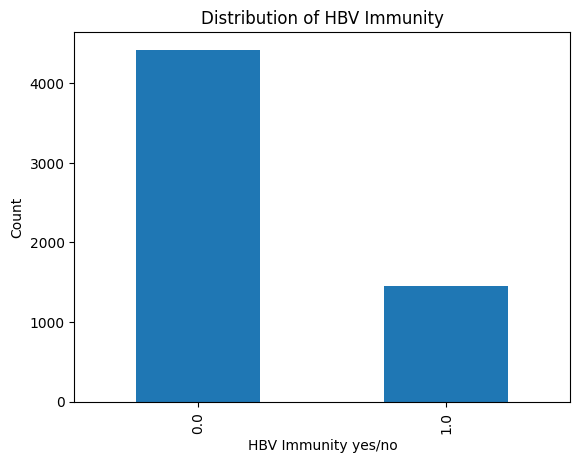

In [20]:
# prompt: plot a plot for the Y.value_counts
Y.value_counts().plot(kind='bar')
plt.title('Distribution of HBV Immunity')
plt.xlabel('HBV Immunity yes/no')
plt.ylabel('Count')
plt.show()

**Checking for Multicollinearity between the variables**

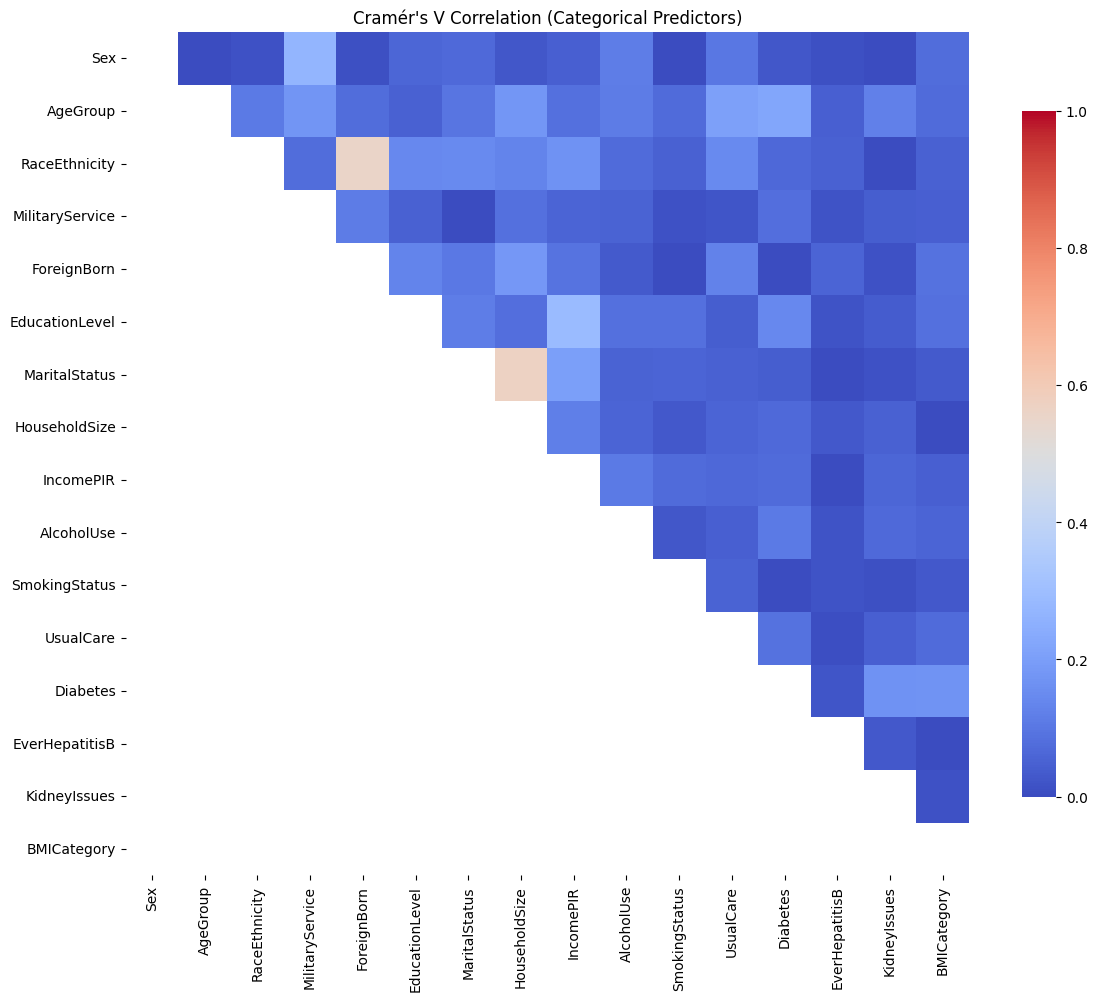


Pairs with Cramér's V ≥ 0.7 (possible redundancy):
  None at or above threshold.


In [21]:
# ==== Multicollinearity among categorical predictors via Cramér's V ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1) Cramér's V (bias-corrected) for two categorical Series
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    tbl = pd.crosstab(x, y, dropna=False)
    # Need at least 2x2 table with variation
    if tbl.shape[0] < 2 or tbl.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(tbl, correction=False)[0]
    n = tbl.values.sum()
    if n == 0:
        return 0.0
    phi2 = chi2 / n
    r, k = tbl.shape
    # Bias correction (Bergsma 2013)
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2corr / denom))

# 2) Ensure everything in X is treated as categorical (string safe-cast)
X_cat = X.copy().astype("category").apply(lambda s: s.astype(str)).fillna("Missing")

cols = X_cat.columns.tolist()
n = len(cols)
cramers = pd.DataFrame(np.eye(n), index=cols, columns=cols)

for i in range(n):
    for j in range(i + 1, n):
        v = cramers_v(X_cat.iloc[:, i], X_cat.iloc[:, j])
        cramers.iat[i, j] = v
        cramers.iat[j, i] = v

# 3) Heatmap (upper triangle)
mask = np.tril(np.ones_like(cramers, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(cramers, mask=mask, cmap="coolwarm", vmin=0, vmax=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Cramér's V Correlation (Categorical Predictors)")
plt.tight_layout()
plt.show()

# 4) Print the strongest pairs (adjust threshold as needed)
THRESH = 0.7  # <-- set your concern threshold here
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((cols[i], cols[j], cramers.iat[i, j]))
strong_pairs = sorted([p for p in pairs if p[2] >= THRESH], key=lambda x: x[2], reverse=True)

print(f"\nPairs with Cramér's V ≥ {THRESH} (possible redundancy):")
if strong_pairs:
    for a, b, v in strong_pairs:
        print(f"  {a}  ~  {b}:  {v:.2f}")
else:
    print("  None at or above threshold.")

# Optional: save matrix for appendix/supplement
# cramers.to_csv("cramers_v_matrix.csv", index=True)


**Apply the Synthetic Minority Over-sampling Technique (SMOTE)**

Class balance (TRAIN):
HBV_Immunity
0.0    4421
1.0    1456
Name: count, dtype: int64 

Class balance (TEST):
HBV_Immunity
0.0    3823
1.0    1375
Name: count, dtype: int64 

Train after SMOTE:
HBV_Immunity
0.0    4421
1.0    4421
Name: count, dtype: int64


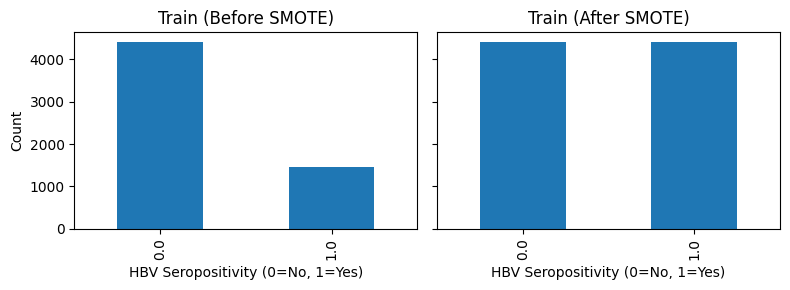

In [29]:
# ==== SMOTE on TRAIN ONLY for all-categorical predictors ====
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 0) Define predictors and outcome explicitly (using your columns)
predictors = [
    'Sex', 'AgeGroup', 'RaceEthnicity', 'MilitaryService', 'ForeignBorn',
    'EducationLevel', 'MaritalStatus', 'HouseholdSize', 'IncomePIR',
    'AlcoholUse', 'SmokingStatus', 'UsualCare', 'Diabetes',
    'EverHepatitisB', 'KidneyIssues', 'BMICategory'
]

target = 'HBV_Immunity'

# 1) Build X_train / y_train from your TRAIN dataset
X_train = train[predictors].copy()
y_train = train[target].copy()

#    Build X_test / y_test from your TEST dataset (kept untouched by SMOTE)
X_test = test[predictors].copy()
y_test = test[target].copy()

print("Class balance (TRAIN):")
print(y_train.value_counts(), "\n")
print("Class balance (TEST):")
print(y_test.value_counts(), "\n")

# 2) Preprocess: impute most-frequent + one-hot for ALL columns (all are categorical)
preprocess_cat = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent")),
                # For sklearn >= 1.2 use sparse_output=False
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            predictors
        )
    ],
    remainder="drop"
)

# 3) Build pipeline: transform -> SMOTE   (no classifier yet)
smote_pipe = ImbPipeline(steps=[
    ("prep", preprocess_cat),
    ("smote", SMOTE(random_state=42))
])

# 4) Fit-resample on TRAINING ONLY
X_resampled, y_resampled = smote_pipe.fit_resample(X_train, y_train)

print("Train after SMOTE:")
print(y_resampled.value_counts())

# 5) Preprocess TEST using the same fitted preprocessing step (no SMOTE)
X_test_preprocessed = smote_pipe.named_steps["prep"].transform(X_test)

# 6) Quick bar plots for train counts before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

y_train.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Train (Before SMOTE)"
)
y_resampled.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Train (After SMOTE)"
)

for ax in axes:
    ax.set_xlabel("HBV Seropositivity (0=No, 1=Yes)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


**Cross-validation For the Analysis**

In [24]:
# ==== Cross-validation with SMOTE for your HBV study ====

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# 0) Define predictors and outcome based on your columns
predictors = [
    'Sex', 'AgeGroup', 'RaceEthnicity', 'MilitaryService', 'ForeignBorn',
    'EducationLevel', 'MaritalStatus', 'HouseholdSize', 'IncomePIR',
    'AlcoholUse', 'SmokingStatus', 'UsualCare', 'Diabetes',
    'EverHepatitisB', 'KidneyIssues', 'BMICategory'
]
target = 'HBV_Immunity'

# X, y from TRAIN dataset only (for CV and training)
X = train[predictors].copy()
y = train[target].copy()

# Just for reference: TEST set for final evaluation
X_test = test[predictors].copy()
y_test = test[target].copy()

print("Train outcome distribution:")
print(y.value_counts(), "\n")
print("Test outcome distribution:")
print(y_test.value_counts(), "\n")

# 1) Preprocess (all predictors are categorical)
preprocess_cat = ColumnTransformer(
    transformers=[
        ("cat",
         Pipeline(steps=[
             ("impute", SimpleImputer(strategy="most_frequent")),
             # use sparse_output=False for sklearn >= 1.2
             ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
         ]),
         predictors
        )
    ],
    remainder="drop"
)

# 2) Model
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # helpful for outcome imbalance
)

# 3) Pipeline: preprocess -> SMOTE (on train folds only) -> RF
rf_pipe = ImbPipeline(steps=[
    ("prep", preprocess_cat),
    ("smote", SMOTE(random_state=42)),
    ("clf", rf)
])

# 4) Stratified 5-fold CV on TRAIN
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_pipe,
    X,
    y,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print(f"CV accuracies: {np.round(cv_scores, 4)}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"SD: {cv_scores.std():.4f}")

# 5) Fit on full TRAIN and evaluate on external TEST set
rf_pipe.fit(X, y)

# Predict on TEST (note: preprocessing + SMOTE only in training)
y_test_pred = rf_pipe.predict(X_test)
y_test_proba = rf_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("\nExternal TEST performance:")
print(f"Accuracy: {test_acc:.4f}")
print(f"AUC:      {test_auc:.4f}")


Train outcome distribution:
HBV_Immunity
0.0    4421
1.0    1456
Name: count, dtype: int64 

Test outcome distribution:
HBV_Immunity
0.0    3823
1.0    1375
Name: count, dtype: int64 

CV accuracies: [0.7151 0.7058 0.7064 0.7055 0.7064]
Mean accuracy: 0.7078
SD: 0.0037

External TEST performance:
Accuracy: 0.7041
AUC:      0.6266


**Model Building and Evaluation**

In [25]:
# ==== Build & evaluate models with SMOTE + RFE nested inside 5-fold CV, then test on hold-out set ====

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

import numpy as np
import pandas as pd

RANDOM_STATE = 42

# -----------------------------
# 1) Preprocess: all predictors categorical
# -----------------------------
preprocess_cat = ColumnTransformer(
    transformers=[
        ("cat",
         Pipeline(steps=[
             ("impute", SimpleImputer(strategy="most_frequent")),
             ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # sklearn ≥1.2
         ]),
         X_train.columns.tolist()  # <-- use X_train columns
        )
    ],
    remainder="drop"
)

# -----------------------------
# 2) RFE selector (inside CV)
#    Use LR as the feature-ranking estimator so it works for any downstream model
# -----------------------------
rfe_ranker = LogisticRegression(
    max_iter=3000,
    solver="liblinear",   # stable for smaller/medium OHE matrices
    random_state=RANDOM_STATE
)

# RFE itself (n_features_to_select will be tuned in CV)
rfe = RFE(
    estimator=rfe_ranker,
    n_features_to_select=50,  # placeholder; tuned by GridSearchCV
    step=0.1                  # drop 10% each iteration (faster than step=1)
)

def make_pipe(est):
    # All steps happen inside CV folds when used in GridSearchCV
    return ImbPipeline(steps=[
        ("prep", preprocess_cat),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("rfe", rfe),
        ("clf", est)
    ])

# -----------------------------
# 3) Models + tuning grids
#    (Keep grids modest; expand if you want deeper tuning)
# -----------------------------
models_and_grids = {
    "LR": (
        LogisticRegression(max_iter=3000, solver="lbfgs"),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__C": [0.1, 1.0, 10.0]
        }
    ),
    "NB": (
        BernoulliNB(),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__alpha": [0.1, 1.0, 2.0]
        }
    ),
    "SVM": (
        SVC(kernel="rbf", probability=True, gamma="scale", random_state=RANDOM_STATE),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__C": [0.5, 1.0, 2.0]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__n_neighbors": [5, 15, 25]
        }
    ),
    "DT": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    ),
    "RF": (
        RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    ),
    "GB": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__learning_rate": [0.05, 0.1],
            "clf__n_estimators": [100, 300]
        }
    ),
    "XGB": (
        XGBClassifier(
            eval_metric="auc",
            tree_method="hist",
            random_state=RANDOM_STATE
        ),
        {
            "rfe__n_features_to_select": [30, 50, 80, 120],
            "clf__n_estimators": [200, 600],
            "clf__max_depth": [3, 4],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample": [0.8, 0.9],
            "clf__colsample_bytree": [0.8, 0.9]
        }
    )
}

# -----------------------------
# 4) CV setup (training only)
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
fitted = {}
best_params_store = {}

for name, (est, param_grid) in models_and_grids.items():
    pipe = make_pipe(est)

    # Grid search: RFE + model tuning happens INSIDE CV folds
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    gs.fit(X_train, y_train)   # trains only on training data (with internal CV)
    best_model = gs.best_estimator_
    fitted[name] = best_model
    best_params_store[name] = gs.best_params_

    # ---- Test-set evaluation (untouched test set) ----
    if hasattr(best_model, "predict_proba"):
        proba = best_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_model, "decision_function"):
        scores = best_model.decision_function(X_test)
        proba = 1 / (1 + np.exp(-scores))
    else:
        proba = None

    pred = best_model.predict(X_test)

    row = {
        "Model": name,
        "CV_best_AUROC": gs.best_score_,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "BalancedAcc": balanced_accuracy_score(y_test, pred)
    }

    if proba is not None:
        row.update({
            "AUROC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba)
        })
    else:
        row.update({"AUROC": np.nan, "PR-AUC": np.nan})

    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("AUROC", ascending=False)

print("\nHold-out Test Performance (unresampled test set; RFE+SMOTE+tuning nested within CV on training only):")
display(results_df.round(3))

print("\nBest parameters selected by CV (includes RFE feature count):")
for k, v in best_params_store.items():
    print(f"{k}: {v}")

# -----------------------------
# 5) Detailed report for best test-set model
# -----------------------------
best_name = results_df.iloc[0]["Model"]
best = fitted[best_name]
best_pred = best.predict(X_test)

print(f"\n=== Detailed report for best model on hold-out test set: {best_name} ===")
print(classification_report(y_test, best_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, best_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=50 > n_features=44. There will be no feature selection and all features will be kept.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=50 > n_features=44. There will be no feature selection and all features will be kept.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=50 > n_features=44. There will be no feature selection and all features will be kept.
  warnings.warn(



Hold-out Test Performance (unresampled test set; RFE+SMOTE+tuning nested within CV on training only):


,Model,CV_best_AUROC,Accuracy,Precision,Recall,F1,BalancedAcc,AUROC,PR-AUC
5,RF,0.657,0.699,0.426,0.394,0.410,0.602,0.674,0.396
6,GB,0.659,0.705,0.432,0.367,0.397,0.597,0.663,0.400
1,NB,0.643,0.595,0.357,0.661,0.463,0.616,0.660,0.381
0,LR,0.657,0.609,0.366,0.653,0.469,0.623,0.660,0.387
7,XGB,0.659,0.722,0.453,0.250,0.322,0.571,0.657,0.395
4,DT,0.630,0.686,0.413,0.438,0.425,0.607,0.648,0.375
2,SVM,0.644,0.683,0.404,0.418,0.411,0.598,0.647,0.385
3,KNN,0.617,0.587,0.349,0.648,0.453,0.606,0.638,0.353



Best parameters selected by CV (includes RFE feature count):
LR: {'clf__C': 10.0, 'rfe__n_features_to_select': 30}
NB: {'clf__alpha': 2.0, 'rfe__n_features_to_select': 30}
SVM: {'clf__C': 0.5, 'rfe__n_features_to_select': 50}
KNN: {'clf__n_neighbors': 25, 'rfe__n_features_to_select': 30}
DT: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'rfe__n_features_to_select': 30}
RF: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'rfe__n_features_to_select': 50}
GB: {'clf__learning_rate': 0.05, 'clf__n_estimators': 100, 'rfe__n_features_to_select': 30}
XGB: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'rfe__n_features_to_select': 50}

=== Detailed report for best model on hold-out test set: RF ===
              precision    recall  f1-score   support

         0.0      0.788     0.809     0.798      3823
         1.0      0.426     0.394     0.410      1375

    accuracy                          0.699    

**Confusion Matrix RF**

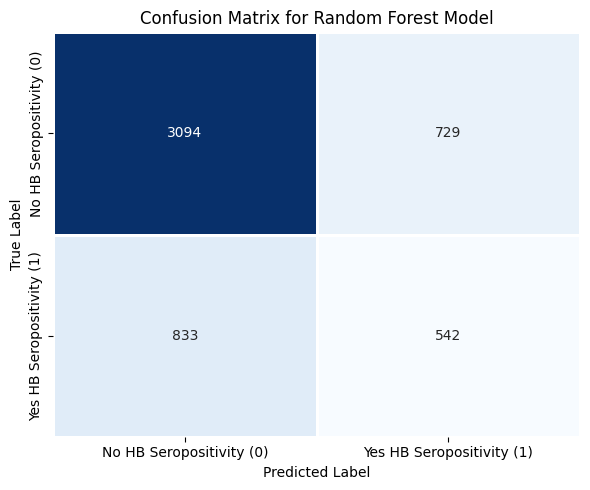


Specificity (True Negative Rate): 0.809
Sensitivity (True Positive Rate): 0.394


In [28]:
# ==== Confusion Matrix for the Best Model (Random Forest (RF) Model) ====

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict class labels using the best model (RF)
y_pred_best = (best.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

labels = ["No HB Seropositivity (0)", "Yes HB Seropositivity (1)"]

# Heatmap visualization
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    cbar=False, linewidths=1
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Random Forest Model")
plt.tight_layout()
plt.show()

# Optional: Class-wise performance rates
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nSpecificity (True Negative Rate): {specificity:.3f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.3f}")

**AUROC Curve/Graph for All Models**

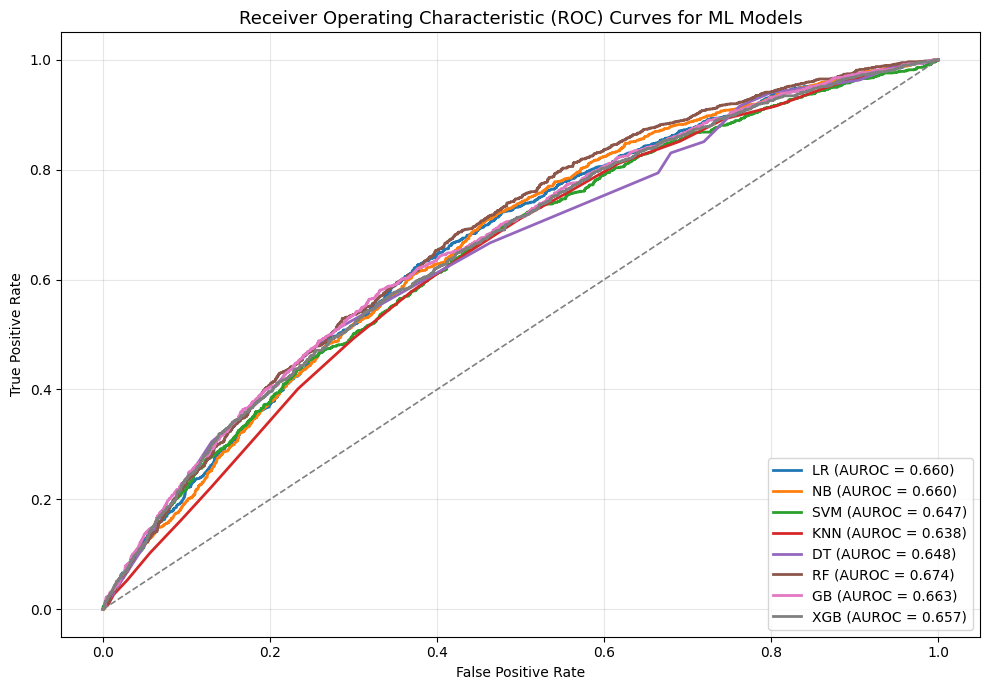

In [30]:
# ==== ROC Curves for All Models ====
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))

# Use the fitted dictionary of trained pipelines from your previous step
for name, model in fitted.items():
    # Predict probabilities for positive class
    y_score = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUROC = {roc_auc:.3f})')

# Add chance line
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.2)

# Styling
plt.title('Receiver Operating Characteristic (ROC) Curves for ML Models', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**The Area Under the Precision Recall (PR) Curve (PR-AUC)**

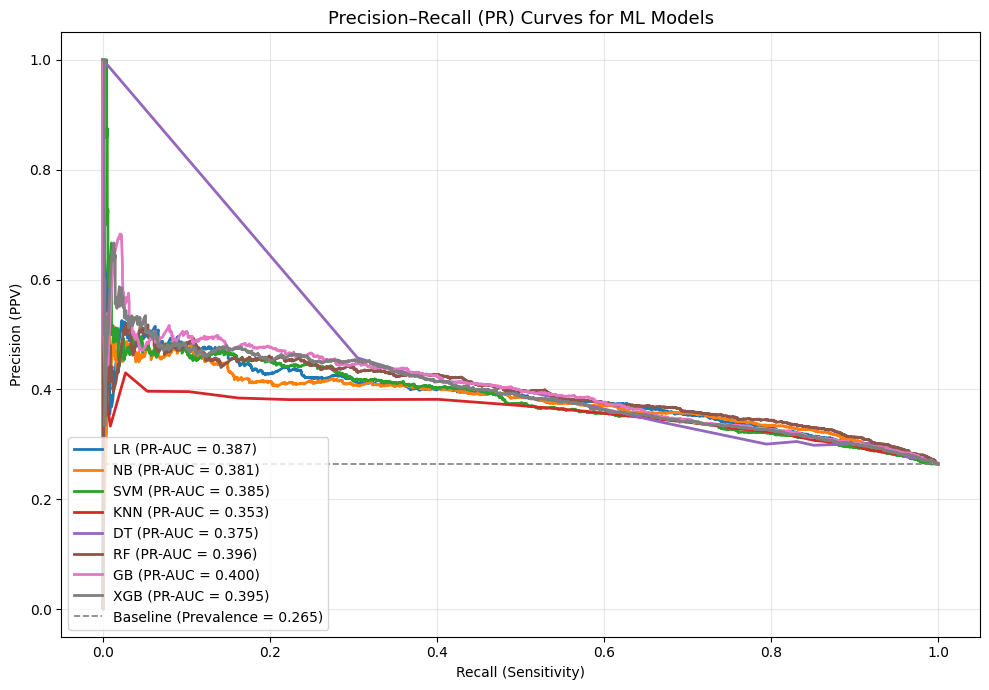

In [31]:
# ==== Precision–Recall (PR) Curves for All Models ====
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))

# Loop through fitted models
for name, model in fitted.items():
    # Predict probabilities for positive class
    y_score = model.predict_proba(X_test)[:, 1]

    # Compute Precision–Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_score)

    # Compute PR-AUC (Average Precision)
    pr_auc = average_precision_score(y_test, y_score)

    # Plot PR curve
    plt.plot(
        recall,
        precision,
        lw=2,
        label=f'{name} (PR-AUC = {pr_auc:.3f})'
    )

# Baseline (prevalence of positive class)
baseline = np.mean(y_test)
plt.hlines(
    y=baseline,
    xmin=0,
    xmax=1,
    colors='grey',
    linestyles='--',
    lw=1.2,
    label=f'Baseline (Prevalence = {baseline:.3f})'
)

# Styling
plt.title('Precision–Recall (PR) Curves for ML Models', fontsize=13)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.legend(loc='lower left', frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Performance Metrics of ML Models Predicting HBV Immunity**

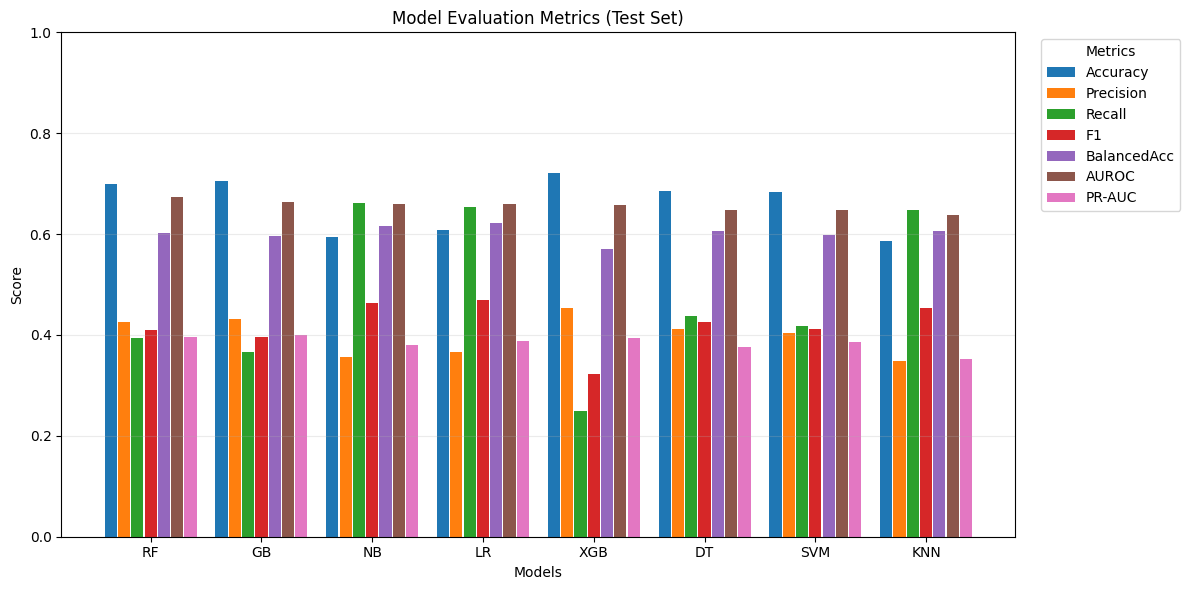

In [32]:
# ==== Grouped bar chart of model metrics (incl. BalancedAcc, PR-AUC) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you already have results_df from earlier, use it; otherwise build it from your lists.
# results_df should have columns: Model, Accuracy, Precision, Recall, F1, BalancedAcc, AUROC, PR-AUC
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "BalancedAcc", "AUROC", "PR-AUC"]

plot_df = results_df.set_index("Model")[metrics_to_plot].copy()
model_names = plot_df.index.tolist()
M = len(model_names)
K = len(metrics_to_plot)

# Bar positions
x = np.arange(M)
bar_w = 0.11
offsets = (np.arange(K) - (K-1)/2) * (bar_w + 0.01)

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + offsets[i], plot_df[metric].values, width=bar_w, label=metric)

# Labels & styling
plt.xticks(x, model_names, rotation=0, fontsize=10)
plt.ylim(0, 1.0)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Evaluation Metrics (Test Set)")
plt.legend(title="Metrics", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

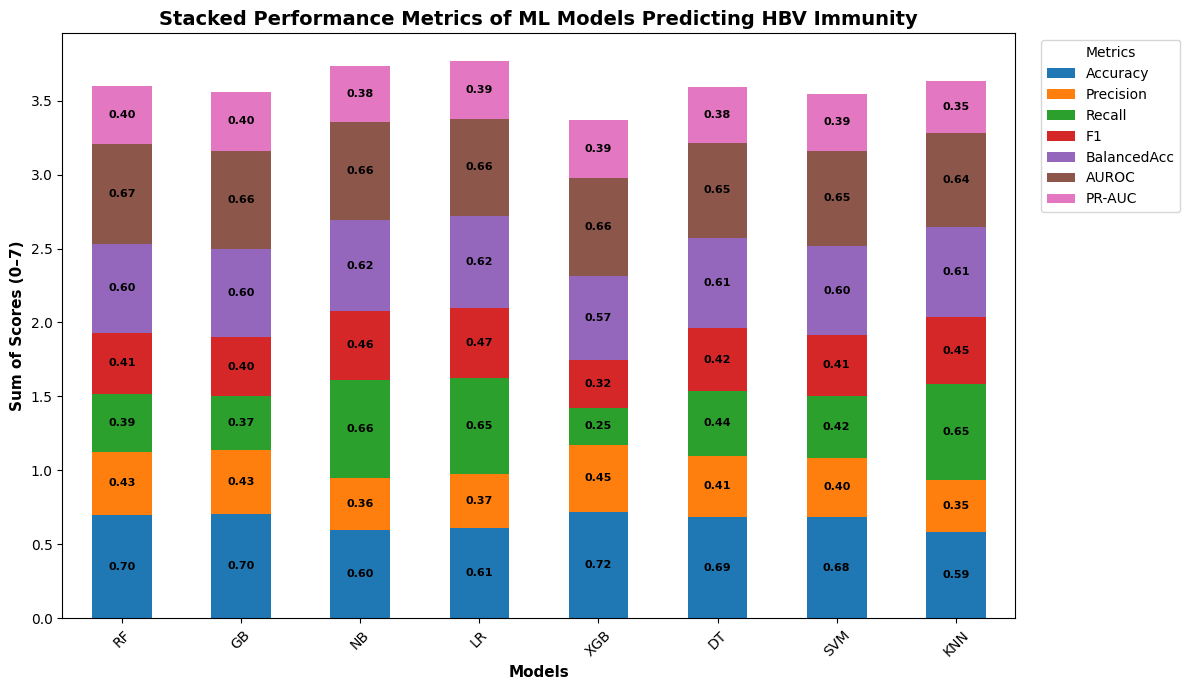

In [33]:
# ==== Stacked Bar Chart for HBV Immunity Model Performance ====

import matplotlib.pyplot as plt

# Select metrics from your results_df
stack_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "BalancedAcc", "AUROC", "PR-AUC"]
].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Generate stacked bar chart
stack_df.plot(kind="bar", stacked=True, ax=ax)

# Titles and axis labels
plt.title("Stacked Performance Metrics of ML Models Predicting HBV Immunity",
          fontsize=14, fontweight="bold")
plt.xlabel("Models", fontsize=11, fontweight="bold")
plt.ylabel("Sum of Scores (0–7)", fontsize=11, fontweight="bold")
plt.xticks(rotation=45)

# Legend placement
plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# === Add metric values inside each stacked segment ===
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        label_type="center",
        fontsize=8,
        color="black",
        fontweight="bold"
    )

plt.show()


**Confusion Matrix for all Models**

In [34]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Initialize list for results
conf_list = []

# Loop through all trained models in the "fitted" dictionary
for name, model in fitted.items():
    # Predict on external NHANES test dataset
    y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

    # Extract confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    conf_list.append({
        "Model": name,
        "TP": tp,   # correctly predicted HBV immunity
        "FP": fp,   # predicted immune but actually not immune
        "FN": fn,   # predicted not immune but actually immune
        "TN": tn    # correctly predicted not immune
    })

# Convert to DataFrame
conf_df = pd.DataFrame(conf_list)

# Optional: enforce consistent ordering of models as in earlier tables
model_order = ["LR", "NB", "SVM", "KNN", "DT", "RF", "GB", "XGB"]
conf_df = conf_df.set_index("Model").loc[model_order].reset_index()

# Display table
print("\nConfusion Matrix Counts for Each Model (External Test Set)")
display(conf_df)



Confusion Matrix Counts for Each Model (External Test Set)


,Model,TP,FP,FN,TN
0,LR,898,1558,477,2265
1,NB,909,1639,466,2184
2,SVM,620,938,755,2885
3,KNN,891,1665,484,2158
4,DT,602,857,773,2966
5,RF,542,729,833,3094
6,GB,504,663,871,3160
7,XGB,344,416,1031,3407


**SHAP (SHapley Additive exPlanations) for the Best-performing Models**

**SHAP Using Random Forest Model**

Top variables by aggregated mean |SHAP| values (RF Lifetime HIV Testing model):


,base,mean_abs_shap
0,AgeGroup,0.101482
4,EducationLevel,0.061513
12,RaceEthnicity,0.039496
2,BMICategory,0.032151
6,ForeignBorn,0.016263
14,SmokingStatus,0.015639
3,Diabetes,0.013882
13,Sex,0.013602
15,UsualCare,0.013550
1,AlcoholUse,0.012204


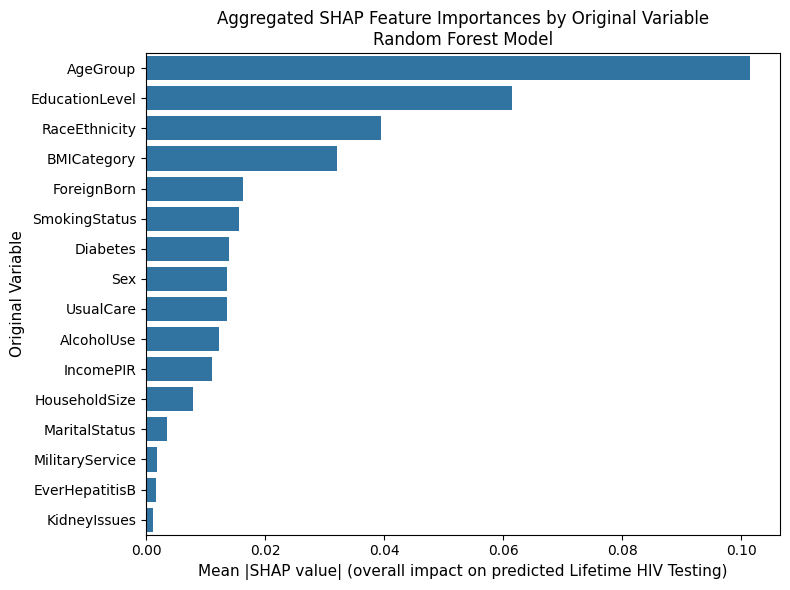


Number of original variables (groups): 16


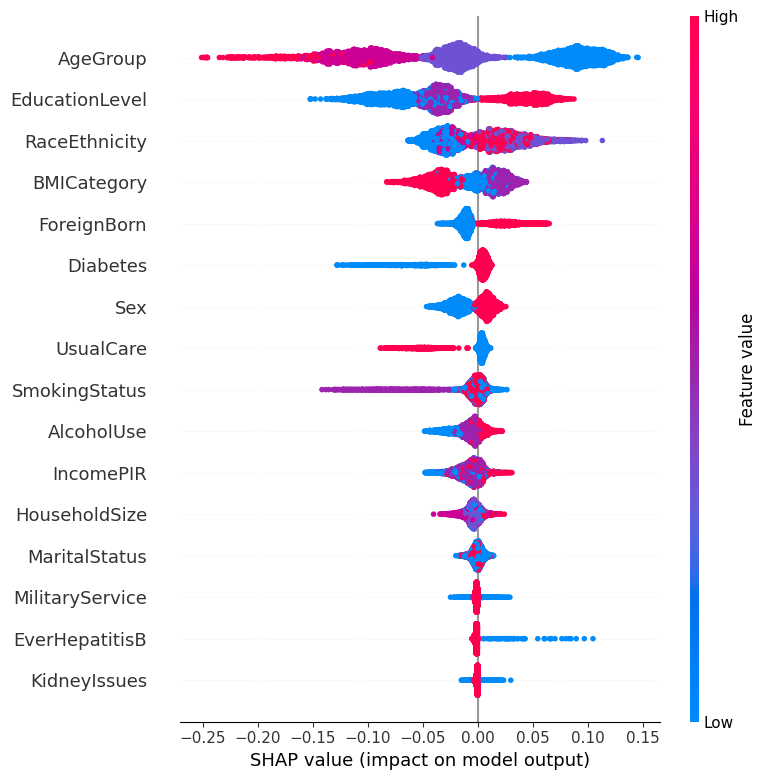

In [35]:
# ==== Aggregated SHAP Feature Importance + Grouped Beeswarm for RF (Lifetime HIV Testing model) ====
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# -------------------------------------------------------------------
# 0) Pull RF pipeline and build SHAP explainer
# -------------------------------------------------------------------
# Assumes:
#   fitted["RF"]  -> trained RF pipeline (prep + smote + clf)
#   X_test        -> original test DataFrame (same columns used in training)
#   y_test        -> binary outcome (0/1)

rf_pipe = fitted["RF"]
prep = rf_pipe.named_steps["prep"]   # ColumnTransformer (impute + OHE)
clf  = rf_pipe.named_steps["clf"]    # RandomForestClassifier

# Transform X_test (no SMOTE at inference)
X_test_tx = prep.transform(X_test)

# ---- Get post-encoding feature names (numeric + one-hot) robustly ----
def _get_feature_names(preprocessor, X_df):
    # Preferred: sklearn >=1.0
    if hasattr(preprocessor, "get_feature_names_out"):
        try:
            return list(preprocessor.get_feature_names_out())
        except Exception:
            pass

    # Fallback: try to reconstruct
    feature_cols = (
        preprocessor.feature_names_in_.tolist()
        if hasattr(preprocessor, "feature_names_in_")
        else X_df.columns.tolist()
    )

    feat_names = []
    if "num" in preprocessor.named_transformers_:
        # numeric features (may be passthrough or a pipeline)
        num_cols = None
        for name, trans, cols in preprocessor.transformers_:
            if name == "num":
                num_cols = cols
                break
        if num_cols is not None:
            feat_names.extend([f"num__{c}" for c in num_cols])

    if "cat" in preprocessor.named_transformers_:
        oh = preprocessor.named_transformers_["cat"].named_steps.get("onehot", None)
        if oh is not None and hasattr(oh, "get_feature_names_out"):
            # if categorical cols were explicitly passed, use them; else use all cols as best guess
            cat_cols = None
            for name, trans, cols in preprocessor.transformers_:
                if name == "cat":
                    cat_cols = cols
                    break
            cat_cols = cat_cols if cat_cols is not None else feature_cols
            feat_names.extend([f"cat__{n}" for n in oh.get_feature_names_out(input_features=cat_cols)])

    return feat_names

feat_names = _get_feature_names(prep, X_test)

# -------------------------------------------------------------------
# 0b) SHAP values for Random Forest
# -------------------------------------------------------------------
explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_test_tx)

# Handle binary output shapes across SHAP versions
if isinstance(shap_vals, list):
    shap_vals_pos = shap_vals[1]          # class-1 (positive) SHAPs
elif getattr(shap_vals, "ndim", 0) == 3:
    shap_vals_pos = shap_vals[:, :, 1]
else:
    shap_vals_pos = shap_vals

# -------------------------------------------------------------------
# 1) Aggregate SHAP values by original variable (post-OHE groups)
# -------------------------------------------------------------------
def base_var(name: str) -> str:
    """
    Convert encoded feature names back to original variable name.

    Handles prefixes like 'cat__' / 'num__' and OHE patterns like:
      'cat__race_ethnicity_3'  -> 'race_ethnicity'
      'num__age'               -> 'age'
    Robust to underscores in original variable name.
    """
    # strip transformer prefix if present
    name = re.sub(r"^(cat|num|remainder)__", "", name)

    # if one-hot: "<original>_<category>" -> strip last chunk
    if "_" in name:
        return name.rsplit("_", 1)[0]
    return name

mean_abs = np.mean(np.abs(shap_vals_pos), axis=0)

agg = (
    pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
      .assign(base=lambda d: d["feature"].map(base_var))
      .groupby("base", as_index=False)["mean_abs_shap"].sum()
      .sort_values("mean_abs_shap", ascending=False)
)

print("Top variables by aggregated mean |SHAP| values (RF Lifetime HIV Testing model):")
display(agg.head(21))

# -------------------------------------------------------------------
# 2) Bar plot of aggregated SHAP importances (original variables)
# -------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    data=agg.head(20),
    x="mean_abs_shap",
    y="base"
)
plt.title("Aggregated SHAP Feature Importances by Original Variable\nRandom Forest Model")
plt.xlabel("Mean |SHAP value| (overall impact on predicted Lifetime HIV Testing)", fontsize=11)
plt.ylabel("Original Variable", fontsize=11)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3) Grouped SHAP beeswarm at original-variable level
# -------------------------------------------------------------------
# Build mapping from encoded features -> base variable
groups = {}
for idx, fname in enumerate(feat_names):
    b = base_var(fname)
    groups.setdefault(b, []).append(idx)

base_vars = list(groups.keys())
print(f"\nNumber of original variables (groups): {len(base_vars)}")

# Grouped SHAP matrix: sum SHAP over one-hot columns for each original variable
n_samples = shap_vals_pos.shape[0]
shap_grouped = np.zeros((n_samples, len(base_vars)))

for j, b in enumerate(base_vars):
    cols = groups[b]
    shap_grouped[:, j] = shap_vals_pos[:, cols].sum(axis=1)

# Matching X matrix (original variables) for coloring in beeswarm
X_grouped = X_test[base_vars].copy()
for col in X_grouped.columns:
    X_grouped[col] = X_grouped[col].astype("category").cat.codes

shap.summary_plot(
    shap_grouped,
    X_grouped.values,
    feature_names=base_vars,
    max_display=21,
    show=True
)


**SHAP Waterfall Plot**

Base value used for waterfall: 0.49989368921058586


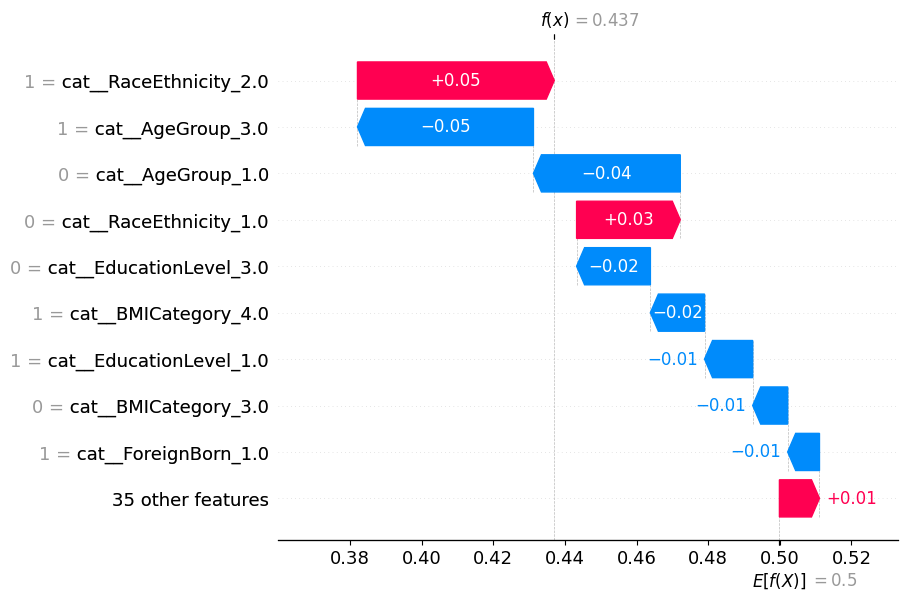

In [36]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) Choose an individual from the test set ----
i = 0   # change index to look at another participant

# ---- 2) Get the base value (expected model output) robustly ----
# (Aligned with the RF code: TreeExplainer(clf) + shap_vals_pos as class-1 SHAPs)
ev = explainer.expected_value

if isinstance(ev, list):
    # binary classifier: [class0_base, class1_base]
    base_value = float(np.array(ev).ravel()[1])
elif isinstance(ev, np.ndarray):
    ev_arr = ev.ravel()
    base_value = float(ev_arr[1]) if ev_arr.size > 1 else float(ev_arr[0])
else:
    base_value = float(ev)

print("Base value used for waterfall:", base_value)

# ---- 3) Ensure we can index the encoded row correctly (sparse vs dense) ----
row_data = X_test_tx[i].toarray().ravel() if hasattr(X_test_tx, "toarray") else np.array(X_test_tx[i]).ravel()

# ---- 4) Build a SHAP Explanation object for that individual ----
shap_expl = shap.Explanation(
    values=shap_vals_pos[i],     # class-1 SHAP values for this person
    base_values=base_value,      # E[f(x)]
    data=row_data,               # encoded features for this person (1D)
    feature_names=feat_names
)

# ---- 5) Waterfall plot ----
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_expl, max_display=10)
plt.show()


Base value used for aggregated waterfall: 0.49989368921058586


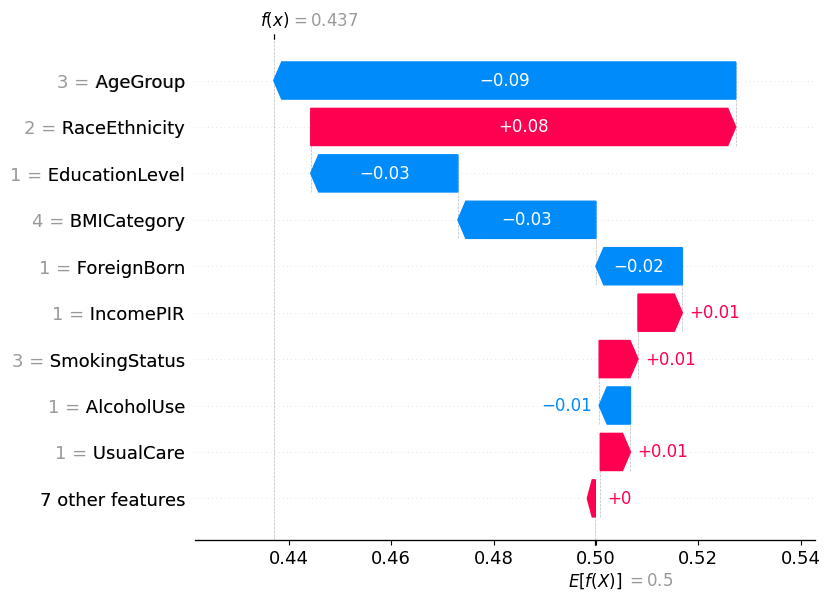

In [37]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Aggregated SHAP Waterfall (Original Variables, RF model)
# ============================================================

# ---- 1) Choose an individual from the test set ----
i = 0   # change index to inspect another participant

# ---- 2) Get base value (class 1) robustly ----
ev = explainer.expected_value

if isinstance(ev, list):
    base_value = float(np.array(ev).ravel()[1])
elif isinstance(ev, np.ndarray):
    ev_arr = ev.ravel()
    base_value = float(ev_arr[1]) if ev_arr.size > 1 else float(ev_arr[0])
else:
    base_value = float(ev)

print("Base value used for aggregated waterfall:", base_value)

# ---- 3) Aggregate SHAP values for this individual by original variable ----
# groups, base_vars were created in the earlier aggregated SHAP section

shap_agg_i = np.zeros(len(base_vars))

for j, b in enumerate(base_vars):
    cols = groups[b]
    shap_agg_i[j] = shap_vals_pos[i, cols].sum()

# ---- 4) Build aggregated feature values for this individual (for display) ----
X_agg_i = X_test[base_vars].iloc[i].copy()

# Convert categories to numeric codes (SHAP expects numeric display)
for col in X_agg_i.index:
    if X_agg_i[col].dtype.name == "category" or X_agg_i[col].dtype == object:
        X_agg_i[col] = X_agg_i[col].astype("category").cat.codes

X_agg_i = X_agg_i.values.astype(float)

# ---- 5) Create SHAP Explanation object (aggregated level) ----
shap_expl_agg = shap.Explanation(
    values=shap_agg_i,
    base_values=base_value,
    data=X_agg_i,
    feature_names=base_vars
)

# ---- 6) Aggregated waterfall plot ----
plt.figure(figsize=(9, 6))
shap.plots.waterfall(
    shap_expl_agg,
    max_display=10   # top 10 original variables
)
plt.show()


**LIME (Local Interpretable Model-agnostic Explanations)**

Intercept 0.4372297892904823
Prediction_local [0.26601662]
Right: 0.4370301614621576
Index 0 predicted P(HBV_Immunity=1): 0.437
Predicted class: 0.0

Original feature values:


,Sex,AgeGroup,RaceEthnicity,MilitaryService,ForeignBorn,EducationLevel,MaritalStatus,HouseholdSize,IncomePIR,AlcoholUse,SmokingStatus,UsualCare,Diabetes,EverHepatitisB,KidneyIssues,BMICategory
0,2.0,3.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,4.0


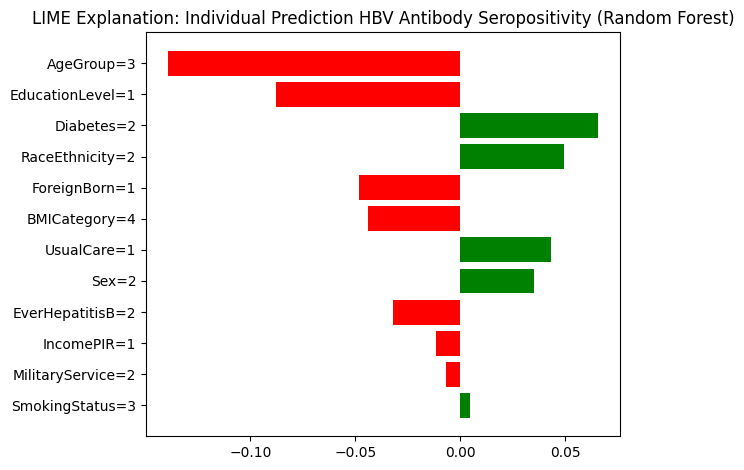


LIME explanation table:


,Feature condition,LIME weight
0,AgeGroup=3,-0.139408
1,EducationLevel=1,-0.087812
2,Diabetes=2,0.065819
3,RaceEthnicity=2,0.049635
4,ForeignBorn=1,-0.048153
5,BMICategory=4,-0.044045
6,UsualCare=1,0.043182
7,Sex=2,0.035151
8,EverHepatitisB=2,-0.032253
9,IncomePIR=1,-0.011437


In [40]:
# ============================================================
# 5) Individual prediction explanation using LIME (Random Forest)
#    HBV Immunity Model
# ============================================================

# 1) Install and import LIME
!pip install lime

from lime import lime_tabular
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 2) Pull the trained Random Forest pipeline
# ------------------------------------------------------------
rf_pipe = fitted["RF"]   # full pipeline: prep -> smote -> clf

# ------------------------------------------------------------
# 3) Prepare training and test data for LIME
#    LIME works in the ORIGINAL feature space, not one-hot space
# ------------------------------------------------------------
X_train_np = X_train.values
X_test_np  = X_test.values

feature_names = X_train.columns.tolist()

# Identify categorical feature indices
cat_features = [X_train.columns.get_loc(c) for c in feature_names]

# Optional: class names for HBV immunity
class_names = ["No HBV Immunity", "HBV Immunity"]

# ------------------------------------------------------------
# 4) Define prediction function for LIME
#    LIME passes numpy arrays; convert back to DataFrame
#    and use the FULL trained RF pipeline
# ------------------------------------------------------------
def predict_proba_lime(X):
    X_df = pd.DataFrame(X, columns=feature_names)
    return rf_pipe.predict_proba(X_df)

# ------------------------------------------------------------
# 5) Build LIME explainer
# ------------------------------------------------------------
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    categorical_features=cat_features,
    discretize_continuous=True,
    mode="classification",
    verbose=True,
    random_state=42
)

# ------------------------------------------------------------
# 6) Explain an individual prediction
# ------------------------------------------------------------
i = 0   # change this index to explain another participant

exp = lime_explainer.explain_instance(
    data_row=X_test_np[i],
    predict_fn=predict_proba_lime,
    num_features=12
)

# Predicted probability for context
proba_i = rf_pipe.predict_proba(X_test.iloc[[i]])[:, 1][0]
pred_i  = rf_pipe.predict(X_test.iloc[[i]])[0]

print(f"Index {i} predicted P(HBV_Immunity=1): {proba_i:.3f}")
print(f"Predicted class: {pred_i}")

# Show original feature values for that individual
print("\nOriginal feature values:")
display(X_test.iloc[[i]])

# ------------------------------------------------------------
# 7) Visualize explanation
# ------------------------------------------------------------
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation: Individual Prediction HBV Antibody Seropositivity (Random Forest)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8) Optional: print explanation as a table
# ------------------------------------------------------------
lime_table = pd.DataFrame(exp.as_list(), columns=["Feature condition", "LIME weight"])
print("\nLIME explanation table:")
display(lime_table)

**Random Forest SHAP dependence plots**

Top 6 variables (RF): ['AgeGroup', 'EducationLevel', 'RaceEthnicity', 'BMICategory', 'ForeignBorn', 'SmokingStatus']


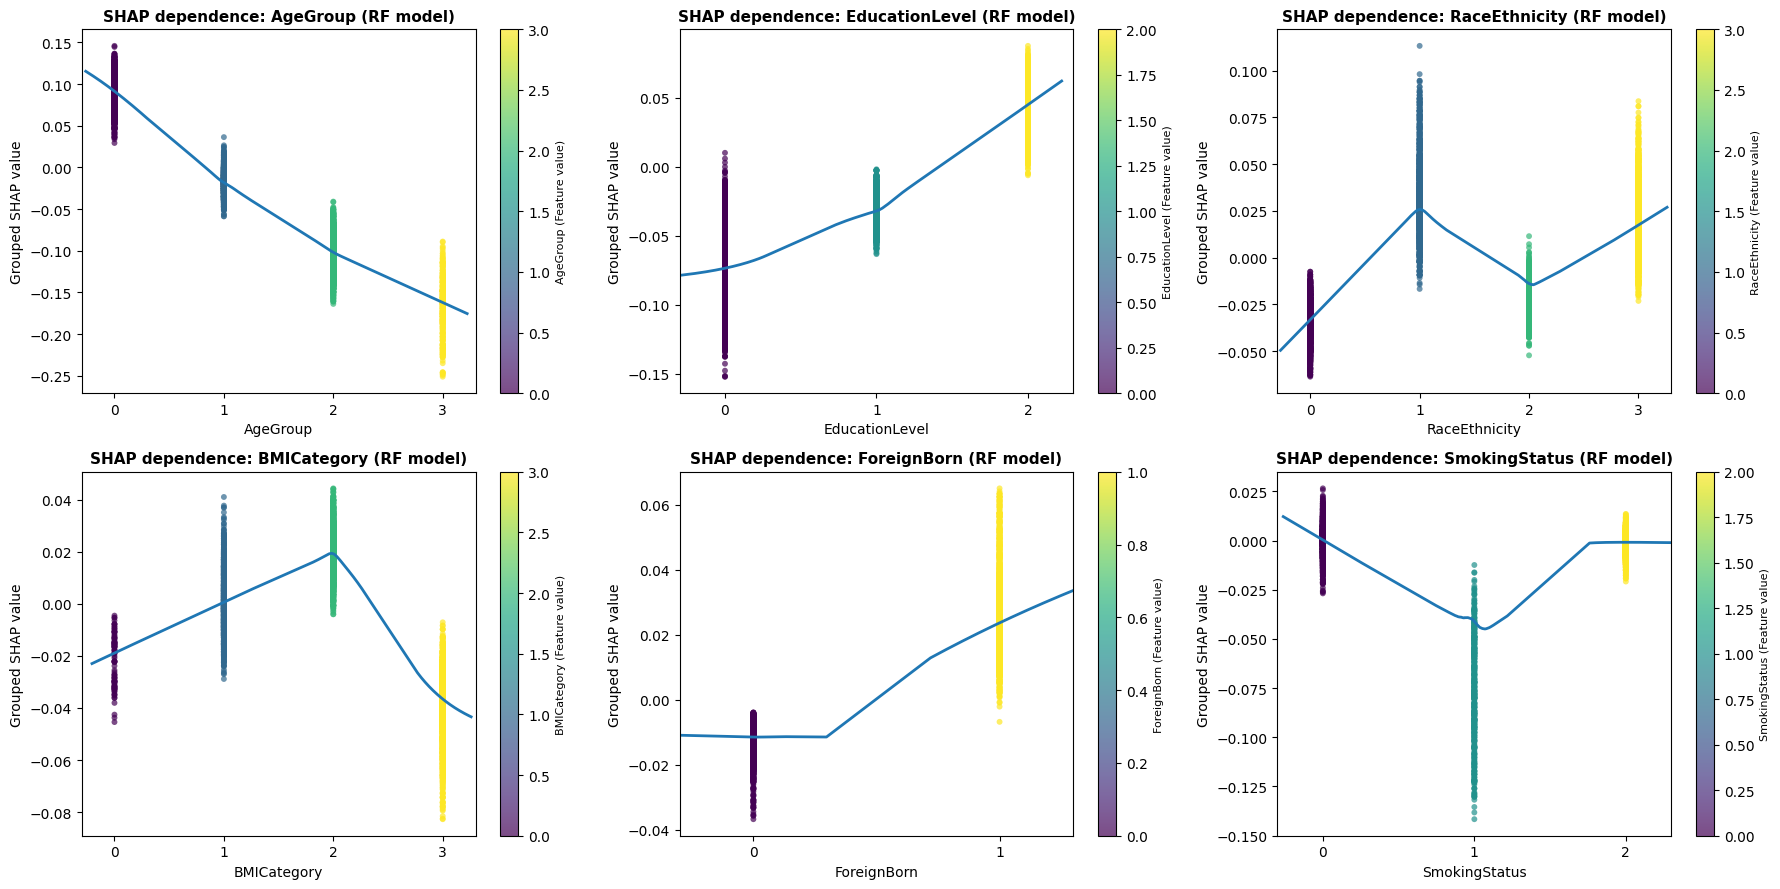

In [41]:
# ==== SHAP dependence plots (2x3) for top 6 original variables – RF model ====
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  # for LOWESS

# This code assumes you already created (from the aggregated RF SHAP code):
#   agg          -> aggregated SHAP table with columns: ["base","mean_abs_shap"]
#   base_vars    -> list of original variable names (same order as shap_grouped columns)
#   shap_grouped -> (n_samples, n_base_vars) grouped SHAP values (summed over OHE)
#   X_grouped    -> DataFrame with original variables (coded numeric) same cols as base_vars

# 1) Select top 6 variables by aggregated mean |SHAP| (RF)
top6_vars = agg.head(6)["base"].tolist()
print("Top 6 variables (RF):", top6_vars)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for k, var in enumerate(top6_vars):
    ax = axes[k]

    # Column index for this variable in shap_grouped
    j = base_vars.index(var)

    # x = coded original variable values, y = grouped SHAP values
    x_raw = X_grouped[var].astype(float).values
    y = shap_grouped[:, j]

    # ---- Scatter: points aligned vertically at each category ----
    sc = ax.scatter(
        x_raw,
        y,
        c=x_raw,          # color by feature value
        s=18,
        alpha=0.7,
        edgecolor="none"
    )

    # ---- LOWESS smooth curve (fit on slightly jittered x) ----
    x_for_smooth = x_raw + np.random.normal(0, 0.08, size=len(x_raw))
    low = sm.nonparametric.lowess(y, x_for_smooth, frac=0.6, return_sorted=True)
    ax.plot(low[:, 0], low[:, 1], linewidth=2)

    # Axis labels & title
    ax.set_title(f"SHAP dependence: {var} (RF model)", fontsize=11, fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Grouped SHAP value")

    # Ticks at actual category codes
    unique_codes = np.sort(np.unique(x_raw))
    ax.set_xticks(unique_codes)
    ax.set_xticklabels(unique_codes.astype(int))

    # Slight padding around x
    ax.set_xlim(unique_codes.min() - 0.3, unique_codes.max() + 0.3)

    # Colorbar for each panel
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"{var} (Feature value)", fontsize=8)

plt.tight_layout()
plt.show()


Top 6 variables (RF): ['AgeGroup', 'EducationLevel', 'RaceEthnicity', 'BMICategory', 'ForeignBorn', 'SmokingStatus']


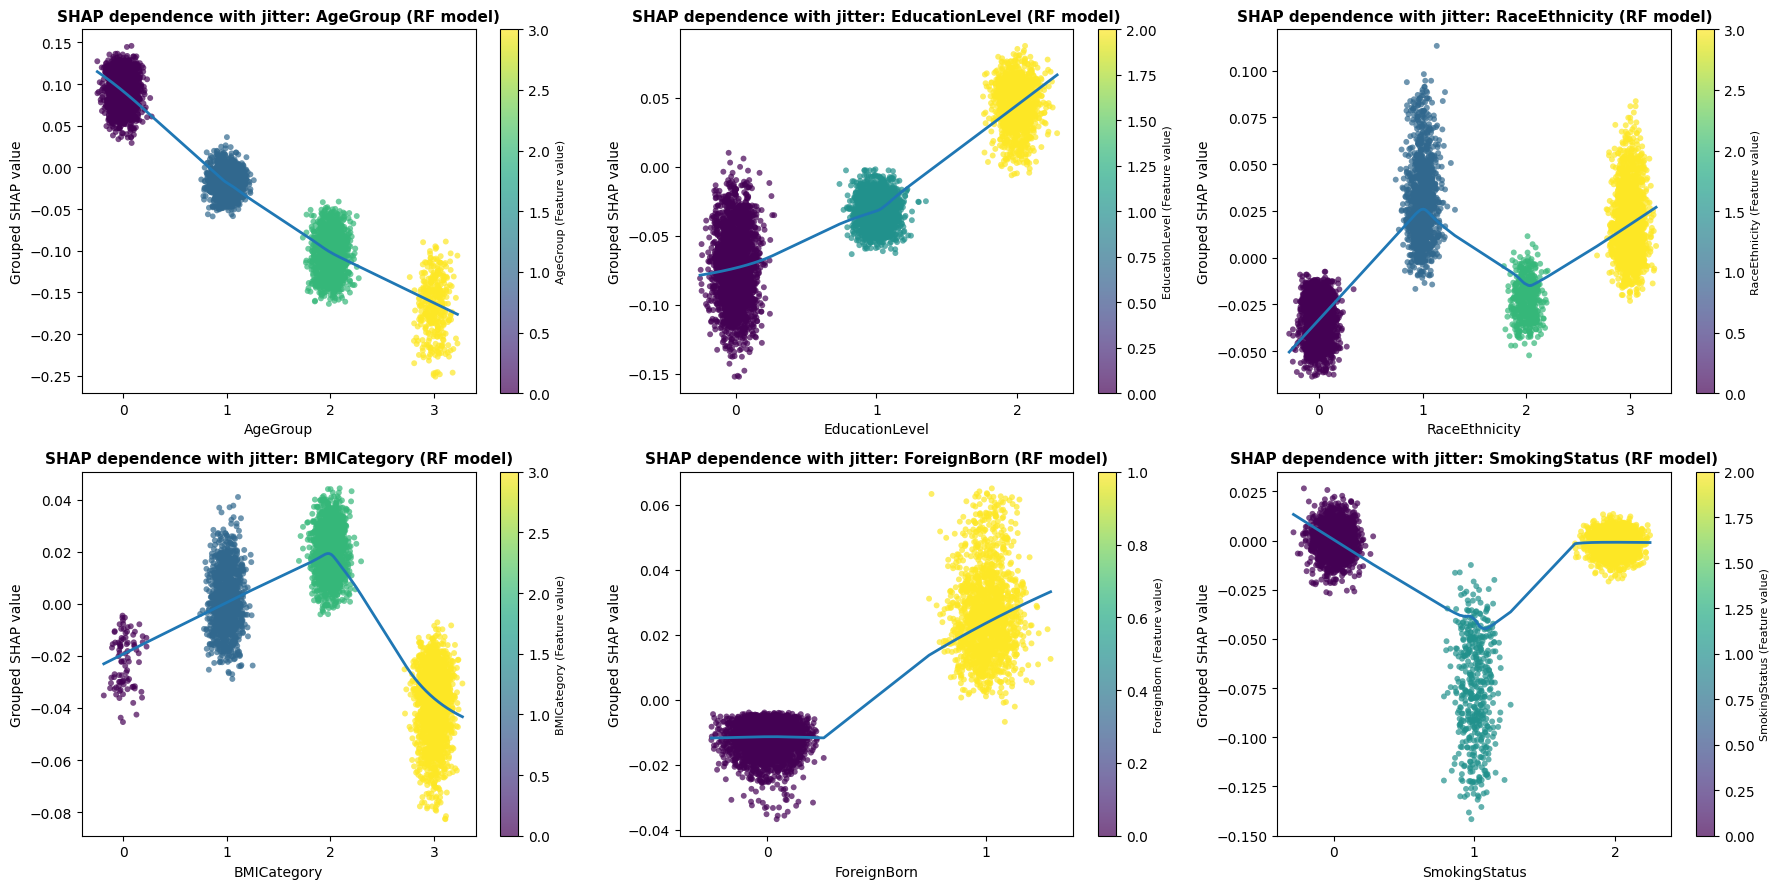

In [42]:
# ==== SHAP dependence plots (2x3) with jitter for top 6 original variables – RF model ====
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  # for LOWESS

# Assumes availability of:
#   agg          -> aggregated SHAP table ["base","mean_abs_shap"]
#   base_vars    -> list of original variable names
#   shap_grouped -> (n_samples, n_base_vars) grouped SHAP values
#   X_grouped    -> DataFrame with original variables (numeric-coded)

# 1) Select top 6 variables by aggregated mean |SHAP| (RF)
top6_vars = agg.head(6)["base"].tolist()
print("Top 6 variables (RF):", top6_vars)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# jitter strength (tune if needed)
jitter_sd = 0.08

for k, var in enumerate(top6_vars):
    ax = axes[k]

    # Column index in grouped SHAP matrix
    j = base_vars.index(var)

    # x = original variable (coded), y = grouped SHAP values
    x_raw = X_grouped[var].astype(float).values
    y = shap_grouped[:, j]

    # ---- Add jitter to x for visualization ----
    x_jitter = x_raw + np.random.normal(0, jitter_sd, size=len(x_raw))

    # ---- Scatter with jitter ----
    sc = ax.scatter(
        x_jitter,
        y,
        c=x_raw,          # color still reflects true (unjittered) value
        s=18,
        alpha=0.7,
        edgecolor="none"
    )

    # ---- LOWESS smooth (fit on jittered x) ----
    low = sm.nonparametric.lowess(
        y,
        x_jitter,
        frac=0.6,
        return_sorted=True
    )
    ax.plot(low[:, 0], low[:, 1], linewidth=2)

    # Titles & labels
    ax.set_title(
        f"SHAP dependence with jitter: {var} (RF model)",
        fontsize=11,
        fontweight="bold"
    )
    ax.set_xlabel(var)
    ax.set_ylabel("Grouped SHAP value")

    # X ticks at actual category codes
    unique_codes = np.sort(np.unique(x_raw))
    ax.set_xticks(unique_codes)
    ax.set_xticklabels(unique_codes.astype(int))

    # Pad x-axis
    ax.set_xlim(unique_codes.min() - 0.4, unique_codes.max() + 0.4)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"{var} (Feature value)", fontsize=8)

plt.tight_layout()
plt.show()


Top 8 variables (RF): ['AgeGroup', 'EducationLevel', 'RaceEthnicity', 'BMICategory', 'ForeignBorn', 'SmokingStatus', 'Diabetes', 'Sex']


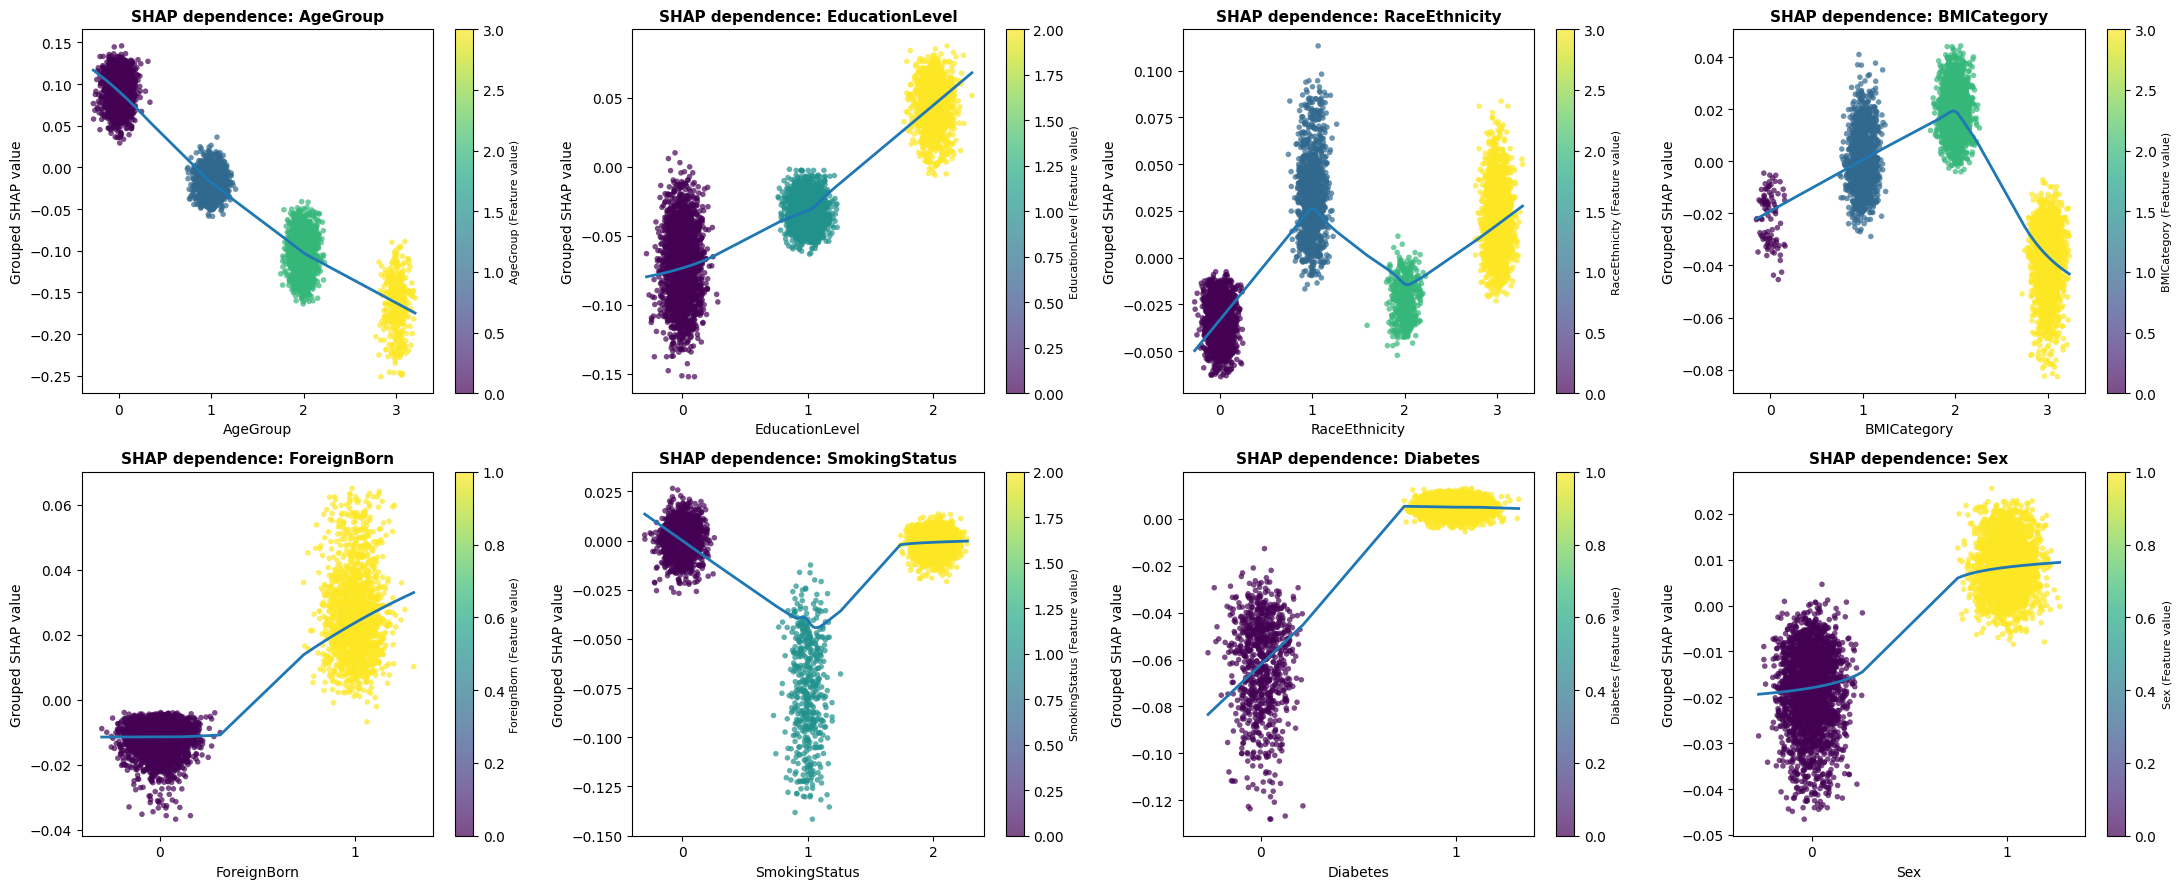

In [43]:
# ==== SHAP dependence plots (2x4) with jitter for top 8 original variables – RF model ====
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  # for LOWESS

# Assumes availability of:
#   agg          -> aggregated SHAP table ["base","mean_abs_shap"]
#   base_vars    -> list of original variable names (order matches shap_grouped columns)
#   shap_grouped -> (n_samples, n_base_vars) grouped SHAP values
#   X_grouped    -> DataFrame with original variables (numeric-coded)

# 1) Select top 8 variables by aggregated mean |SHAP| (RF)
top8_vars = agg.head(8)["base"].tolist()
print("Top 8 variables (RF):", top8_vars)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.ravel()

# jitter strength (tune if needed)
jitter_sd = 0.08

for k, var in enumerate(top8_vars):
    ax = axes[k]

    # Column index in grouped SHAP matrix
    j = base_vars.index(var)

    # x = coded original variable values, y = grouped SHAP values
    x_raw = X_grouped[var].astype(float).values
    y = shap_grouped[:, j]

    # ---- Add jitter to x for visualization ----
    x_jitter = x_raw + np.random.normal(0, jitter_sd, size=len(x_raw))

    # ---- Scatter with jitter ----
    sc = ax.scatter(
        x_jitter,
        y,
        c=x_raw,         # color reflects true (unjittered) value
        s=16,
        alpha=0.7,
        edgecolor="none"
    )

    # ---- LOWESS smooth curve (fit on jittered x) ----
    low = sm.nonparametric.lowess(y, x_jitter, frac=0.6, return_sorted=True)
    ax.plot(low[:, 0], low[:, 1], linewidth=2)

    # Titles & labels
    ax.set_title(f"SHAP dependence: {var}", fontsize=11, fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Grouped SHAP value")

    # X ticks at actual category codes
    unique_codes = np.sort(np.unique(x_raw))
    ax.set_xticks(unique_codes)
    ax.set_xticklabels(unique_codes.astype(int))

    # Pad x-axis for jitter
    ax.set_xlim(unique_codes.min() - 0.4, unique_codes.max() + 0.4)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"{var} (Feature value)", fontsize=8)

# Hide any unused axes (in case fewer than 8)
for ax in axes[len(top8_vars):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Top 8 variables (RF): ['AgeGroup', 'EducationLevel', 'RaceEthnicity', 'BMICategory', 'ForeignBorn', 'SmokingStatus', 'Diabetes', 'Sex']


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


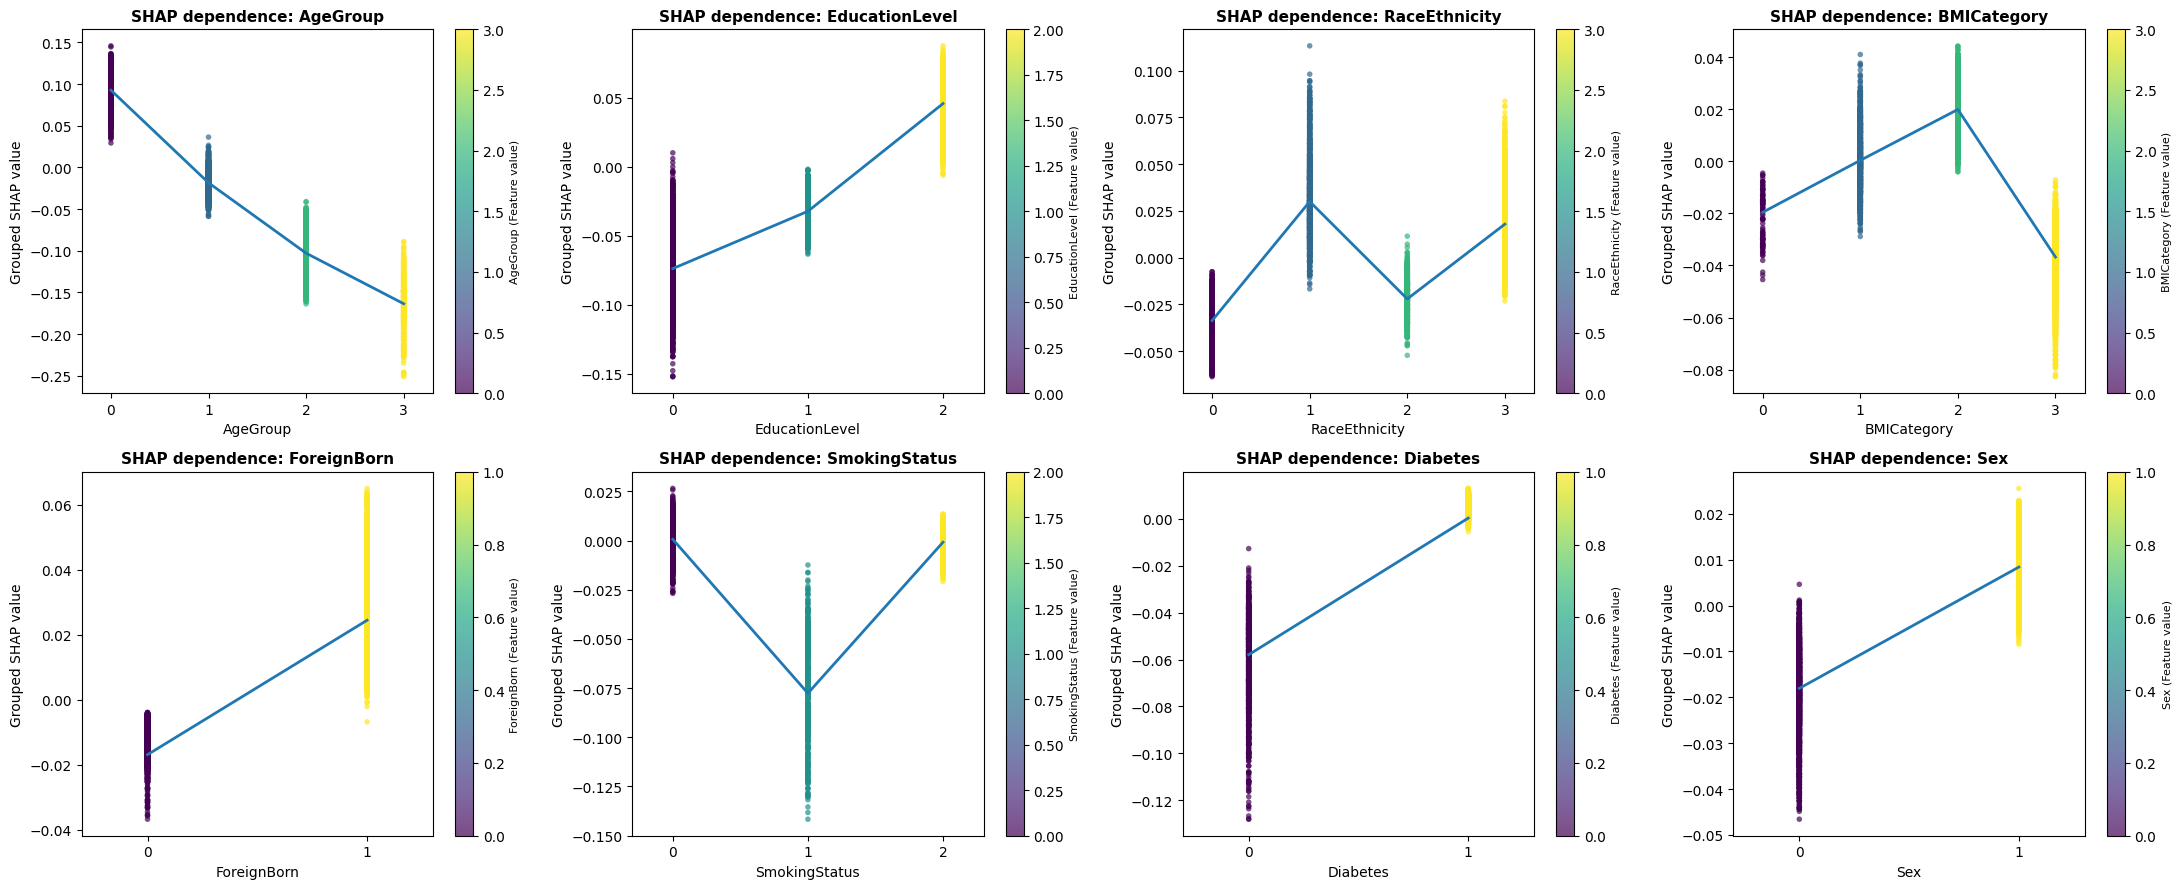

In [45]:
# ==== SHAP dependence plots (2x4) WITHOUT jitter for top 8 original variables – RF model ====
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  # for LOWESS

# Assumes availability of:
#   agg          -> aggregated SHAP table ["base","mean_abs_shap"]
#   base_vars    -> list of original variable names (order matches shap_grouped columns)
#   shap_grouped -> (n_samples, n_base_vars) grouped SHAP values
#   X_grouped    -> DataFrame with original variables (numeric-coded)

# 1) Select top 8 variables by aggregated mean |SHAP| (RF)
top8_vars = agg.head(8)["base"].tolist()
print("Top 8 variables (RF):", top8_vars)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.ravel()

for k, var in enumerate(top8_vars):
    ax = axes[k]

    # Column index in grouped SHAP matrix
    j = base_vars.index(var)

    # x = coded original variable values, y = grouped SHAP values
    x_raw = X_grouped[var].astype(float).values
    y = shap_grouped[:, j]

    # ---- Scatter (no jitter) ----
    sc = ax.scatter(
        x_raw,
        y,
        c=x_raw,          # color reflects feature value
        s=16,
        alpha=0.7,
        edgecolor="none"
    )

    # ---- LOWESS smooth curve (no jitter) ----
    low = sm.nonparametric.lowess(
        y,
        x_raw,
        frac=0.6,
        return_sorted=True
    )
    ax.plot(low[:, 0], low[:, 1], linewidth=2)

    # Titles & labels
    ax.set_title(f"SHAP dependence: {var}", fontsize=11, fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Grouped SHAP value")

    # X ticks at actual category codes
    unique_codes = np.sort(np.unique(x_raw))
    ax.set_xticks(unique_codes)
    ax.set_xticklabels(unique_codes.astype(int))

    # Slight padding around x-axis
    ax.set_xlim(unique_codes.min() - 0.3, unique_codes.max() + 0.3)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"{var} (Feature value)", fontsize=8)

# Hide any unused axes
for ax in axes[len(top8_vars):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
